# Online Dictionary Learning and Bilevel Optimization

How can a dictionary adapt to new observations while still representing the old ones?
This project compares Frank–Wolfe (FW) and an away-step variant (AFW) on that problem.
A dictionary is a collection of reusable vectors, called **atoms**. Each observation
is approximated by a weighted combination of a few atoms.

We first learn 40 atoms from 250 old observations, then expand to 50 atoms for
200 new observations. All observations have 25 features. The experiment uses
synthetic data so that we can also compare learned atoms with the generating dictionary.

In [1]:
from pathlib import Path
from time import perf_counter
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import minimize, linear_sum_assignment
from threadpoolctl import threadpool_limits
from IPython.display import display

FIGURES = Path('figures')
FIGURES.mkdir(exist_ok=True)
plt.rcParams.update({'figure.dpi': 120, 'font.size': 10})
RADIUS = 3.0
SEEDS = [123, 124, 125]
LEARN_STEPS, REFINE_STEPS, ONLINE_STEPS = 500, 10000, 1000
LOWER_GAP_TOL = 1e-7

## 1. Synthetic data

Each signal uses five nonzero coefficients and a small amount of Gaussian noise
(standard deviation 0.01). Old signals use atoms 1–40; new signals use atoms 31–50.
This creates an overlap of 10 atoms and introduces 10 previously unused atoms.
The true dictionary is used only for generating data and measuring recovery, not for training.

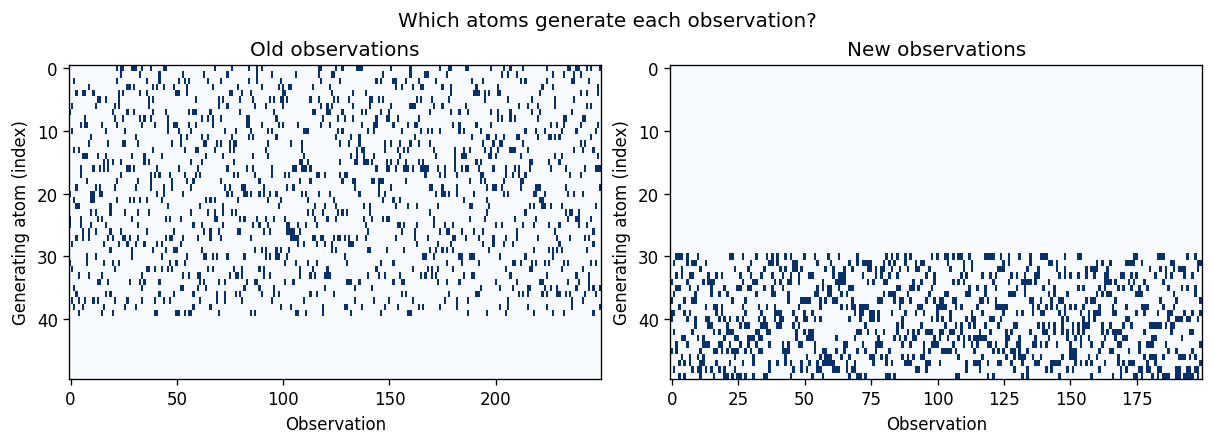

Old data: (25, 250) | New data: (25, 200) | True dictionary: (25, 50)


In [2]:
def generate_data(seed):
    rng = np.random.default_rng(seed)
    truth = rng.normal(size=(25, 50))
    truth /= np.linalg.norm(truth, axis=0)
    def signals(count, available):
        coefficients = np.zeros((50, count))
        for j in range(count):
            indices = rng.choice(available, 5, replace=False)
            coefficients[indices, j] = rng.uniform(0.2, 1, 5) * rng.choice([-1, 1], 5)
        return truth @ coefficients + 0.01 * rng.normal(size=(25, count)), coefficients
    old, old_codes = signals(250, np.arange(40))
    new, new_codes = signals(200, np.arange(30, 50))
    return truth, old, new, old_codes, new_codes

truth, old, new, old_codes, new_codes = generate_data(SEEDS[0])
fig, axes = plt.subplots(1, 2, figsize=(10, 3.6), constrained_layout=True)
for ax, coefficients, title in zip(axes, [old_codes, new_codes], ['Old observations', 'New observations']):
    im = ax.imshow(coefficients != 0, aspect='auto', cmap='Blues', interpolation='nearest')
    ax.set(title=title, xlabel='Observation', ylabel='Generating atom (index)')
fig.suptitle('Which atoms generate each observation?')
fig.savefig(FIGURES / 'data_structure.png', bbox_inches='tight')
plt.show()
print('Old data:', old.shape, '| New data:', new.shape, '| True dictionary:', truth.shape)

**Reading the plot:** Each blue mark indicates a nonzero coefficient: that atom was used to generate that observation. White means the atom was not used. The vertical axis uses zero-based indices: old observations use atoms **0?39**, and new observations use **30?49**. Atoms **30?39** are shared; **40?49** appear only in the new data. Each observation uses five atoms. This plot describes the synthetic data generation, not the learned dictionary or algorithm performance.

## 2. Objective and comparison

For data $Y$, dictionary $D$ and coefficients $X$, the reconstruction loss is
$L(D,X;Y)=\|Y-DX\|_F^2/(2n)$, where $n$ is the number of observations.
Each dictionary column has Euclidean norm at most 1, and each coefficient column
has absolute values summing to at most 3. The latter encourages sparsity; it does
not require exactly five nonzero coefficients in learned representations.

**FW** moves coefficients towards a signed coordinate vector. **AFW** can also
move away from a previously selected vector. It keeps explicit nonnegative weights
whose sum is one. Away steps are limited by the selected vector's weight, so the
coefficients remain feasible. Both methods use the same FW dictionary update;
the away-step comparison concerns the coefficient updates.

We prepare one common dictionary and old coefficient matrix per seed using FW,
then fix those coefficients and refine the dictionary until its convex FW gap is
at most $10^{-7}$. This gap bounds the remaining lower-level objective error for
the fixed coefficients; it does not certify joint dictionary/coefficient learning. During adaptation, the old coefficients remain fixed.
The lower-level objective is the old-data loss; the upper-level objective is the
new-data loss. A linearized lower-level constraint guides each dictionary update:

$$\langle\nabla g(D),S-D\rangle\le g(D_0)-g(D).$$

Here $D_0$ is the refined initial dictionary. Its loss is an approximate reference,
not a known global optimum. This is a numerical approximation to the simple bilevel
problem: a linearized constraint does **not** guarantee that the actual old loss
never increases. We therefore report both losses and the observed old-loss drift.

In [3]:
def loss(D, X, Y):
    return np.sum((D @ X - Y)**2) / (2 * Y.shape[1])

def dictionary_vertex(gradient):
    norms = np.linalg.norm(gradient, axis=0)
    return np.divide(-gradient, norms, out=np.zeros_like(gradient), where=norms > 0)

def recovery(D, truth, threshold=0.9):
    # Normalize copies: evaluating a metric must not change the fitted dictionary.
    normalized = D / np.maximum(np.linalg.norm(D, axis=0), 1e-15)
    target = truth / np.maximum(np.linalg.norm(truth, axis=0), 1e-15)
    correlations = np.abs(normalized.T @ target)
    rows, columns = linear_sum_assignment(-correlations)
    return np.count_nonzero(correlations[rows, columns] > threshold) / truth.shape[1]

def initial_weights(atoms, samples):
    # Represent zero using actual vertices +radius*e_0 and -radius*e_0.
    weights = np.zeros((2 * atoms, samples))
    weights[0] = weights[atoms] = 0.5
    return weights

def coefficients(weights):
    atoms = weights.shape[0] // 2
    return RADIUS * (weights[:atoms] - weights[atoms:2*atoms])

def coefficient_step(D, Y, weights, method):
    if method not in {'FW', 'AFW'}:
        raise ValueError('method must be FW or AFW')
    X = coefficients(weights)
    atoms, samples = X.shape
    residual = D @ X - Y
    gradient = D.T @ residual
    scores = np.vstack([RADIUS * gradient, -RADIUS * gradient])
    columns = np.arange(samples)
    towards = np.argmin(scores, axis=0)
    current_score = np.sum(gradient * X, axis=0)
    fw_gap = current_score - scores[towards, columns]
    away = np.argmax(np.where(weights > 1e-14, scores, -np.inf), axis=0)
    away_gap = scores[away, columns] - current_score
    use_away = (away_gap > fw_gap + 1e-14) & (method == 'AFW')
    selected = np.where(use_away, away, towards)
    vertex = np.zeros_like(X)
    nonzero = selected < 2 * atoms
    vertex[selected[nonzero] % atoms, columns[nonzero]] = np.where(selected[nonzero] < atoms, RADIUS, -RADIUS)
    direction = np.where(use_away[None, :], X - vertex, vertex - X)
    weight = weights[away, columns]
    limit = np.where(use_away, weight / np.maximum(1-weight, 1e-15), 1.0)
    projected = D @ direction
    denominator = np.sum(projected**2, axis=0)
    numerator = -np.sum(residual * projected, axis=0)
    step = np.clip(numerator / np.maximum(denominator, 1e-30), 0, limit)
    updated = weights * np.where(use_away, 1+step, 1-step)[None, :]
    updated[selected, columns] += np.where(use_away, -step, step)
    assert np.min(updated) >= -1e-10
    updated = np.maximum(updated, 0)
    updated /= updated.sum(axis=0)
    return updated, int(np.count_nonzero(use_away & (step > 1e-14)))

def dictionary_step(D, X, Y):
    residual = D @ X - Y
    gradient = residual @ X.T
    direction = dictionary_vertex(gradient) - D
    projected = direction @ X
    step = np.clip(-np.sum(residual * projected) / max(np.sum(projected**2), 1e-30), 0, 1)
    return D + step * direction

def constrained_vertex(upper_gradient, lower_gradient, beta):
    """Minimize <U,S> over column unit balls and <G,S> <= beta.

    The dual multiplier is nonnegative. At a zero combined-gradient column,
    the optimizer is a face of the ball: choose a point on that face that
    meets the halfspace, rather than assuming every column is a unit vector.
    """
    U, G = upper_gradient, lower_gradient
    norms = np.linalg.norm(G, axis=0)
    minimum = -norms.sum()
    tolerance = 1e-10 * max(1.0, abs(beta), norms.sum())
    if beta < minimum - tolerance:
        raise ValueError('Infeasible dictionary halfspace')
    unconstrained = dictionary_vertex(U)
    if np.sum(G * unconstrained) <= beta + tolerance:
        return unconstrained
    if beta <= minimum + 1e-13:
        candidate = dictionary_vertex(G)
        free = norms == 0
        candidate[:, free] = dictionary_vertex(U[:, free])
        return candidate

    def evaluate(multiplier):
        combined = U + multiplier * G
        combined_norms = np.linalg.norm(combined, axis=0)
        candidate = dictionary_vertex(combined)
        zero = combined_norms <= 1e-12 * max(1.0, np.linalg.norm(U), multiplier*np.linalg.norm(G))
        if np.any(zero):
            candidate[:, zero] = 0
            fixed = np.sum(G * candidate)
            capacity = norms[zero].sum()
            if capacity > 0 and abs(beta-fixed) <= capacity + tolerance:
                # Set the free columns to meet the constraint exactly.
                fraction = np.clip((beta-fixed)/capacity, -1, 1)
                candidate[:, zero] = -fraction * dictionary_vertex(G[:, zero])
        constraint = np.sum(G*candidate) - beta
        primal = np.sum(U*candidate)
        dual = -np.linalg.norm(combined, axis=0).sum() - multiplier*beta
        return candidate, constraint, primal-dual

    low, high = 0.0, 1.0
    for _ in range(100):
        candidate, violation, gap = evaluate(high)
        if violation <= 0:
            break
        high *= 2
    else:
        raise RuntimeError('Could not bracket the dictionary multiplier')
    for _ in range(150):
        multiplier = (low+high)/2
        candidate, violation, gap = evaluate(multiplier)
        if violation <= tolerance and abs(gap) <= 1e-8 * max(1.0, abs(np.sum(U*candidate))):
            assert np.max(np.linalg.norm(candidate, axis=0)) <= 1+1e-10
            return candidate
        if violation > 0:
            low = multiplier
        else:
            high = multiplier
    raise RuntimeError('Dictionary oracle did not meet primal/dual tolerances')

def lower_gap(D, X, Y):
    gradient = (D @ X - Y) @ X.T / Y.shape[1]
    return float(np.sum(gradient * (D-dictionary_vertex(gradient))))

## Numerical checks

These checks test gradients by finite differences, FW/AFW on a known sparse-coding
solution, feasibility and descent, and dictionary linear subproblems against an
independent SciPy solver. A scalar case with a zero combined gradient has the known
answer 0.25 and checks the oracle's handling of non-unique minimizers.

In [4]:
def check_implementation():
    rng = np.random.default_rng(7)
    D, X, Y = rng.normal(size=(3, 4)), rng.normal(size=(4, 5)), rng.normal(size=(3, 5))
    residual = D@X-Y
    for block, gradient in [('D', residual@X.T/5), ('X', D.T@residual/5)]:
        direction = rng.normal(size=gradient.shape)
        eps = 1e-6
        if block == 'D':
            numeric = (loss(D+eps*direction, X, Y)-loss(D-eps*direction, X, Y))/(2*eps)
        else:
            numeric = (loss(D, X+eps*direction, Y)-loss(D, X-eps*direction, Y))/(2*eps)
        assert np.isclose(numeric, np.sum(gradient*direction), rtol=1e-6, atol=1e-7)
    for method in ['FW', 'AFW']:
        target = np.array([[1., 4.], [-.5, -1.]])
        expected = np.array([[1., 3.], [-.5, 0.]])
        weights = initial_weights(2, 2)
        previous = loss(np.eye(2), coefficients(weights), target)
        for _ in range(2000):
            weights, _ = coefficient_step(np.eye(2), target, weights, method)
            value = loss(np.eye(2), coefficients(weights), target)
            assert value <= previous+1e-10
            assert np.min(weights)>=0 and np.allclose(weights.sum(axis=0), 1)
            assert np.max(np.abs(coefficients(weights)).sum(axis=0)) <= RADIUS+1e-10
            previous = value
        assert np.allclose(coefficients(weights), expected, atol=1e-5)
    U, G = np.array([[-1.]]), np.array([[1.]])
    assert np.allclose(constrained_vertex(U, G, .25), [[.25]], atol=1e-8)
    assert np.allclose(constrained_vertex(U, G, -1.), [[-1.]])
    try:
        constrained_vertex(U, G, -1.1)
        raise AssertionError('An infeasible oracle call must fail')
    except ValueError:
        pass
    for _ in range(10):
        U, G = rng.normal(size=(3, 2)), rng.normal(size=(3, 2))
        beta = -.3*np.linalg.norm(G, axis=0).sum()
        candidate = constrained_vertex(U, G, beta)
        constraints = [
            {'type': 'ineq', 'fun': lambda z: 1-np.sum(z.reshape(3, 2)**2, axis=0),
             'jac': lambda z: np.array([(-2*z.reshape(3, 2)*[1, 0]).ravel(), (-2*z.reshape(3, 2)*[0, 1]).ravel()])},
            {'type': 'ineq', 'fun': lambda z: beta-np.sum(G*z.reshape(3, 2)), 'jac': lambda z: -G.ravel()}]
        # Start from a different feasible point, not the candidate being tested.
        start = .5*dictionary_vertex(G)
        reference = minimize(lambda z: np.sum(U*z.reshape(3, 2)), start.ravel(),
                             method='SLSQP', jac=lambda z: U.ravel(), constraints=constraints,
                             options={'ftol': 1e-9, 'maxiter': 500})
        assert reference.success, reference.message
        assert np.max(np.linalg.norm(candidate, axis=0)) <= 1+1e-9
        assert np.sum(G*candidate) <= beta+1e-8
        assert abs(np.sum(U*candidate)-reference.fun) < 1e-6
    before = D.copy()
    truth = rng.normal(size=D.shape)
    truth_before = truth.copy()
    recovery(D, truth)
    assert np.array_equal(D, before) and np.array_equal(truth, truth_before)
    assert recovery(np.array([[1., 1.], [0., 0.]]), np.eye(2)) == .5
    print('Passed: gradients; FW/AFW known solutions, feasibility and descent; oracle boundary and cancellation cases; 10 independent solver comparisons; recovery checks.')

check_implementation()

Passed: gradients; FW/AFW known solutions, feasibility and descent; oracle boundary and cancellation cases; 10 independent solver comparisons; recovery checks.


## 3. Run a matched comparison

Each seed uses one shared preparation: 500 alternating FW learning iterations,
followed by dictionary-only refinement if needed (at most 10,000 iterations).
Both online methods receive exact copies of the same dictionary and old coefficients,
so their lower-level objectives and starting points are identical. They start with
zero new coefficients and each run 1,000 adaptation iterations.
The 10 additional atoms start as random unit vectors shared across methods; the
old coefficient matrix is extended with zeros. This lets the new atoms learn
without changing the representation of the old observations at initialization.
Coefficient updates use an exact quadratic line search. Initial dictionary updates
also use line search; adaptation uses a shared step schedule, $0.3/\sqrt{t+1}$.

Three seeds give a small check of sensitivity to initialization and generated data.
They are not a large benchmark. Timings cover online adaptation and its numerical
checks only, excluding shared preparation, data generation, and plotting, with one
numerical-library thread. They vary by machine. This is an alternating block method:
AFW applies to the coefficient block only, not the whole dictionary/coefficient pair.
The updates are not an exact implementation of joint CG-BiO or full-space AFW.

In [5]:
def prepare_problem(seed):
    # A shared lower-level problem makes the online FW/AFW comparison paired.
    truth, old, new, _, _ = generate_data(seed)
    rng = np.random.default_rng(seed + 1000)
    D = rng.normal(size=(25, 40))
    D /= np.linalg.norm(D, axis=0)
    weights = initial_weights(40, 250)
    learning_loss = []
    for _ in range(LEARN_STEPS):
        weights, _ = coefficient_step(D, old, weights, 'FW')
        X_old = coefficients(weights)
        D = dictionary_step(D, X_old, old)
        learning_loss.append(loss(D, X_old, old))
    gap = lower_gap(D, X_old, old)
    for refinement in range(REFINE_STEPS):
        if gap <= LOWER_GAP_TOL:
            break
        D = dictionary_step(D, X_old, old)
        learning_loss.append(loss(D, X_old, old))
        gap = lower_gap(D, X_old, old)
    assert gap <= LOWER_GAP_TOL, f'Lower-level refinement failed: gap={gap}'
    assert np.all(np.diff(learning_loss) <= 1e-9)
    extra = rng.normal(size=(25, 10))
    extra /= np.linalg.norm(extra, axis=0)
    D = np.hstack([D, extra])
    X_old = np.pad(X_old, ((0, 10), (0, 0)))
    return dict(truth=truth, old=old, new=new, D=D, X_old=X_old,
                learning=learning_loss, lower_gap=gap)

def run_experiment(seed, method, problem):
    truth, old, new = problem['truth'], problem['old'], problem['new']
    D, X_old = problem['D'].copy(), problem['X_old'].copy()
    reference = loss(D, X_old, old)
    weights = initial_weights(50, 200)
    online_old = [reference]
    online_new = [loss(D, coefficients(weights), new)]
    away_count = 0
    start = perf_counter()
    for iteration in range(ONLINE_STEPS):
        weights, count = coefficient_step(D, new, weights, method)
        away_count += count
        X_new = coefficients(weights)
        upper_gradient = (D @ X_new - new) @ X_new.T / new.shape[1]
        lower_gradient = (D @ X_old - old) @ X_old.T / old.shape[1]
        beta = reference - loss(D, X_old, old) + np.sum(lower_gradient * D)
        vertex = constrained_vertex(upper_gradient, lower_gradient, beta)
        assert np.sum(lower_gradient*vertex) <= beta + 1e-8
        step = 0.3 / np.sqrt(iteration + 1)
        D = (1-step) * D + step * vertex
        online_old.append(loss(D, X_old, old))
        online_new.append(loss(D, X_new, new))
        assert np.max(np.linalg.norm(D, axis=0)) <= 1+1e-10
        assert np.max(np.sum(np.abs(X_new), axis=0)) <= RADIUS+1e-10
    seconds = perf_counter()-start
    assert np.all(np.isfinite(online_new)) and np.all(np.isfinite(online_old))
    row = dict(seed=seed, method=method, old_before=reference, old_after=online_old[-1],
               new_loss=online_new[-1], old_drift=online_old[-1]-reference,
               max_old_drift=max(online_old)-reference, lower_gap=problem['lower_gap'],
               recovery=recovery(D, truth), seconds=seconds, away_steps=away_count)
    trace = dict(learning=problem['learning'], old=online_old, new=online_new,
                 dictionary=D, initial_dictionary=problem['D'], truth=truth)
    return row, trace

rows, traces = [], {}
with threadpool_limits(limits=1):
    for seed in SEEDS:
        problem = prepare_problem(seed)
        for method in ['FW', 'AFW']:
            row, trace = run_experiment(seed, method, problem)
            rows.append(row)
            traces[seed, method] = trace
            print(f"Seed {seed}, {method}: new loss={row['new_loss']:.5f}, old loss={row['old_after']:.5f}, {row['seconds']:.2f}s")
results = pd.DataFrame(rows)
display(results.round(8))

Seed 123, FW: new loss=0.06171, old loss=0.02531, 1.90s


Seed 123, AFW: new loss=0.05875, old loss=0.02531, 1.93s


Seed 124, FW: new loss=0.08820, old loss=0.02792, 1.93s


Seed 124, AFW: new loss=0.08495, old loss=0.02792, 1.91s


Seed 125, FW: new loss=0.06059, old loss=0.02014, 1.97s


Seed 125, AFW: new loss=0.05720, old loss=0.02014, 2.06s


,seed,method,old_before,old_after,new_loss,old_drift,max_old_drift,lower_gap,recovery,seconds,away_steps
0,123,FW,0.025315,0.025315,0.061714,-0.0,0.000002,3.000000e-08,0.34,1.900481,0
1,123,AFW,0.025315,0.025315,0.058748,0.0,0.000002,3.000000e-08,0.36,1.925644,101181
2,124,FW,0.027920,0.027920,0.088201,0.0,0.000001,6.000000e-08,0.18,1.926810,0
3,124,AFW,0.027920,0.027920,0.084954,-0.0,0.000001,6.000000e-08,0.18,1.908749,98960
4,125,FW,0.020144,0.020144,0.060591,0.0,0.000035,8.000000e-08,0.56,1.966053,0
5,125,AFW,0.020144,0.020144,0.057203,0.0,0.000036,8.000000e-08,0.56,2.058638,99542


## 4. Results and convergence curves

Loss means average half-squared reconstruction error per observation; lower is better.
It is a training reconstruction measure, not classification accuracy or held-out performance.
The table summarizes all three runs; the curves show seed 123 only.
Old-loss drift is measured against the shared starting dictionary for each seed.
The saved table includes the largest temporary increase, not just the final loss.

new_loss           old_before           old_after           old_drift  \
            mean       std       mean       std      mean       std      mean   
method                                                                          
FW      0.070169  0.015626   0.024459  0.003958  0.024459  0.003958       0.0   
AFW     0.066969  0.015595   0.024459  0.003958  0.024459  0.003958       0.0   

            max_old_drift            recovery             seconds            
        std          mean       std      mean       std      mean       std  
method                                                                       
FW      0.0      0.000012  0.000019  0.360000  0.190788  1.931115  0.032998  
AFW     0.0      0.000013  0.000020  0.366667  0.190088  1.964344  0.082097

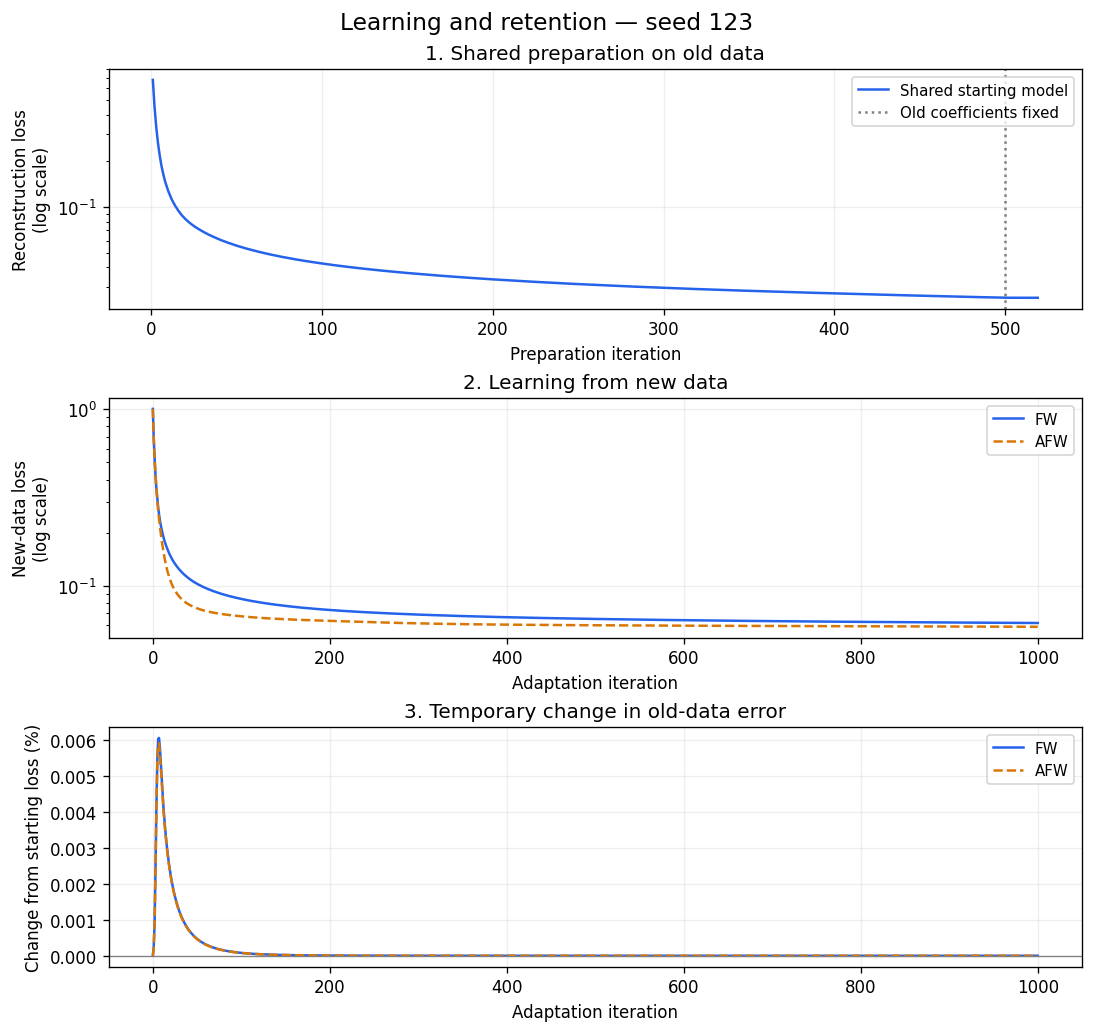

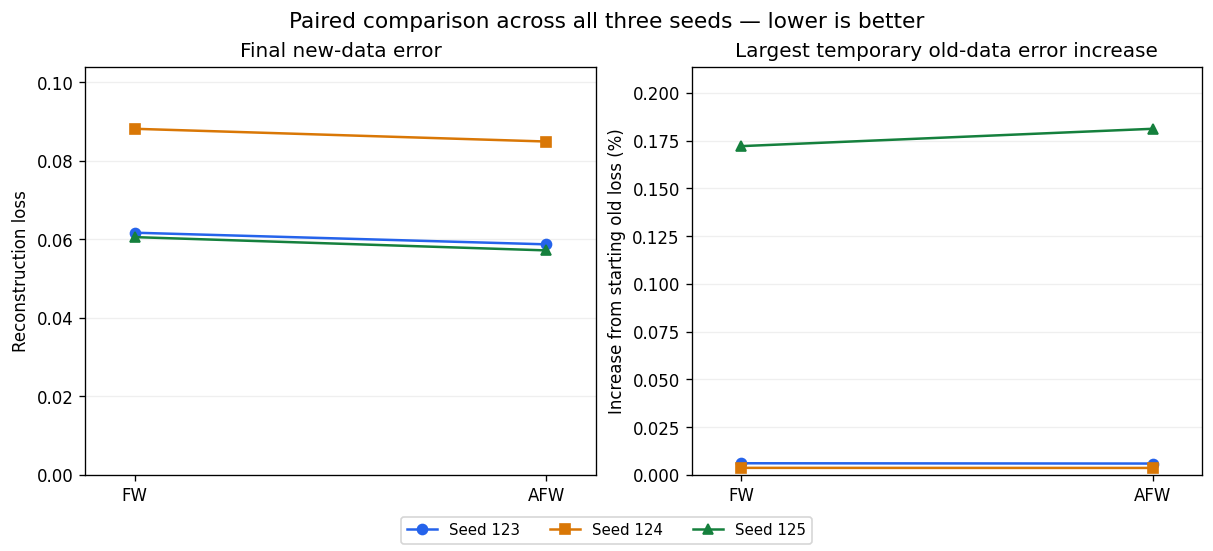

In [6]:
summary = results.groupby('method', sort=False)[['new_loss', 'old_before', 'old_after', 'old_drift', 'max_old_drift', 'recovery', 'seconds']].agg(['mean', 'std'])
display(summary.round(6))

# Show one representative trajectory; the paired figure below covers every seed.
seed = SEEDS[0]
fig, axes = plt.subplots(3, 1, figsize=(9, 8.5), constrained_layout=True)
learning = traces[seed, 'FW']['learning']
axes[0].semilogy(np.arange(1, len(learning)+1), learning, color='#2563eb', label='Shared starting model')
axes[0].axvline(LEARN_STEPS, color='gray', linestyle=':', label='Old coefficients fixed')
axes[0].set(title='1. Shared preparation on old data', xlabel='Preparation iteration', ylabel='Reconstruction loss\n(log scale)')
for method, color, style in [('FW', '#2563eb', '-'), ('AFW', '#d97706', '--')]:
    trace = traces[seed, method]
    axes[1].semilogy(trace['new'], color=color, linestyle=style, label=method)
    old_loss = np.asarray(trace['old'])
    relative_change = 100*(old_loss-old_loss[0])/old_loss[0]
    axes[2].plot(relative_change, color=color, linestyle=style, label=method)
    # Final plotted values must agree with the numerical result table.
    row = results[(results.seed == seed) & (results.method == method)].iloc[0]
    assert np.isclose(trace['new'][-1], row.new_loss)
    assert np.isclose(old_loss[-1]-old_loss[0], row.old_drift, atol=1e-12)
axes[1].set(title='2. Learning from new data', xlabel='Adaptation iteration', ylabel='New-data loss\n(log scale)')
axes[2].set(title='3. Temporary change in old-data error', xlabel='Adaptation iteration', ylabel='Change from starting loss (%)')
axes[2].axhline(0, color='gray', linewidth=0.8)
axes[2].ticklabel_format(axis='y', style='plain', useOffset=False)
for ax in axes:
    ax.grid(alpha=0.2)
    ax.legend(fontsize=9, loc='upper right')
fig.suptitle(f'Learning and retention — seed {seed}', fontsize=14)
fig.savefig(FIGURES/'convergence.png', bbox_inches='tight')
plt.show()

# Pair methods by seed; lines connect the same data and starting model.
comparison = results.copy()
comparison['peak_old_percent'] = 100*comparison.max_old_drift/comparison.old_before
fig, axes = plt.subplots(1, 2, figsize=(10, 4.5), constrained_layout=True)
for ax, metric, title, ylabel in zip(
    axes, ['new_loss', 'peak_old_percent'],
    ['Final new-data error', 'Largest temporary old-data error increase'],
    ['Reconstruction loss', 'Increase from starting old loss (%)']):
    for seed, color, marker in zip(SEEDS, ['#2563eb', '#d97706', '#15803d'], ['o', 's', '^']):
        pair = comparison[comparison.seed == seed].set_index('method').loc[['FW', 'AFW'], metric]
        ax.plot([0, 1], pair.to_numpy(), color=color, marker=marker, label=f'Seed {seed}')
    ax.set_xticks([0, 1], ['FW', 'AFW'])
    ax.set_xlim(-0.12, 1.12)
    ax.set_ylim(0, comparison[metric].max()*1.18)
    ax.set(title=title, ylabel=ylabel)
    ax.grid(axis='y', alpha=0.2)
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='outside lower center', ncol=3, fontsize=9)
fig.suptitle('Paired comparison across all three seeds — lower is better', fontsize=13)
fig.savefig(FIGURES/'comparison.png', bbox_inches='tight')
plt.show()


In [7]:
means = results.groupby('method').mean(numeric_only=True)
improvement = 100 * (means.loc['FW', 'new_loss'] - means.loc['AFW', 'new_loss']) / means.loc['FW', 'new_loss']
print(f'AFW reduced mean new-data loss by {improvement:.1f}% relative to FW across these three seeds.')
print(f"Mean dictionary recovery: FW {100*means.loc['FW', 'recovery']:.1f}%, AFW {100*means.loc['AFW', 'recovery']:.1f}%.")
print(f"Largest absolute old-loss drift across all iterations: {max(np.max(np.abs(np.array(t['old'])-t['old'][0])) for t in traces.values()):.2e}.")

AFW reduced mean new-data loss by 4.6% relative to FW across these three seeds.
Mean dictionary recovery: FW 36.0%, AFW 36.7%.
Largest absolute old-loss drift across all iterations: 3.65e-05.


## 5. Interpreting the outcome

Compare final new-data loss together with old-loss drift and runtime. A lower new
loss alone does not prove better retention or a universally faster algorithm.
AFW achieves lower new-data loss in all three runs. Old-data loss can temporarily
increase because the dictionary constraint is linearized; inspect the maximum drift
as well as the final loss. No universal speed advantage is claimed.
Away steps can remove weight from unhelpful coefficient directions, but their
extra bookkeeping can also cost time. The saved table reports how often they were used.

Dictionary recovery uses a maximum-total-similarity one-to-one assignment between
learned and true atoms, then counts matches with absolute cosine similarity above
0.9. Matching ignores signs and ordering but cannot reuse a learned atom. It is a
diagnostic rather than proof of exact dictionary recovery.

The experiment processes one old batch and one new batch; it is not a deployed
streaming system. Joint dictionary/coefficient learning is nonconvex, the lower-level
solution is approximate, and three synthetic seeds are insufficient to claim general
convergence rates or performance on unseen real data. The useful lesson is to assess
adaptation, retention, and computational cost together.

## References

- [Jiang et al. (2023), A Conditional Gradient-based Method for Simple Bilevel Optimization with Convex Lower-level Problem](https://proceedings.mlr.press/v206/jiang23a.html): a related simple-bilevel formulation for online dictionary learning. This notebook is a practical comparison, not an exact reproduction of that paper's experiments or convergence guarantees.
- [Lacoste-Julien and Jaggi (2015), On the Global Linear Convergence of Frank-Wolfe Optimization Variants](https://arxiv.org/abs/1511.05932): background on Frank–Wolfe and away-step updates. Its theoretical rates are not asserted for the full nonconvex experiment here.